<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 1 - The Bandit Task</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

### Objectives:
Through this series of exercises, you will:
1. Familiarize yourself with the two-armed (restless) bandit task
2. Understand how cognitive models can be used to:
    - Simulate behavior on a cognitive task
    - Generate a variety of behaviors depending on their parameter settings
3. Characterize human behavior with a cognitive model

### Library imports and installs

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from rl_model import RLModel

# 1. The Two-armed Restless Bandit Task

## Play it!

The best way to understand a task is to try it! You will now play the 2-armed restless bandit task and save your decision trajectory.  
To run the Bandit app, first make sure you have installed the `gradio` python package. The app is local, so all the computations will be done on your computer and nothing will be sent out to the internet. The code for the app is in the `bandit_app.py` file.

📝 Run the app and play the task until the end:
1. Execute the cell below.
2. If the app doesn't show up in the notebook, you can also click or copy-paste the given URL in your browser.

In [3]:
%run bandit_app.py

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


The app saves your actions and rewards automatically at the end of the game.

We will keep them aside for now and come back to them at the end.

## Visualize the Bandit values
To better understand what happens during the bandit task, let's plot the value of the two bandit arms over the trials to visualize their trajectories.  
The `bandit_data.npy` file contains the sequence of rewards for both arms for 80 trials.  
This is why, when you load the data, you will obtain a matrix of dimensions 2 x 80.

In [4]:
bandit_data = np.load('bandit_data.npy')
bandit_data.shape

(2, 80)

📝 Complete the code below in order to plot the trajectories of the two arms on the game you played.  
For this you will need to use a very well-known library called `matplotlib`. Don't hesitate to ask for guidance if it's your first time using this library.

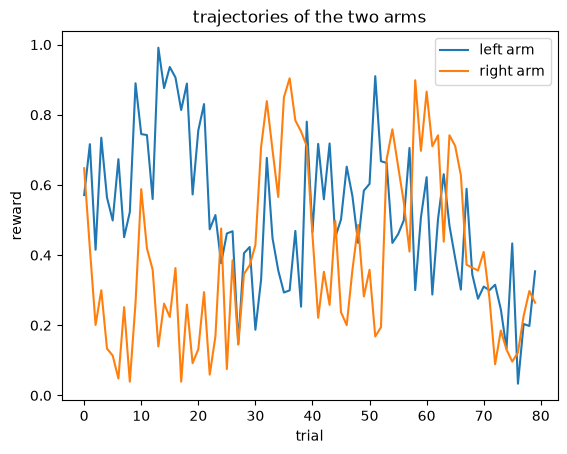

In [5]:
left_arm = bandit_data[0]
right_arm = bandit_data[1]

plt.plot(left_arm, label="left arm")  # This line will plot the trajectory of the left arm
plt.plot(right_arm, label="right arm")
# Complete this code to:
#       1- Display the trajectory of the right arm on top of the other one
#       2- Add a title and x and y axis labels

######
plt.xlabel("trial")
plt.ylabel("reward")
plt.legend()
plt.title("trajectories of the two arms")
plt.show()

# Understanding how to use a cognitive model

## Simulate behavior with a model

We will simulate the behavior of a Reinforcement Learning model on this task. For now, there is no need to understand how it works internally, we will go back to it over the course of the semester. For now, you will get familiar with the way we use it to generate behavior on the two-armed restless bandit task.

### A) Instantiate your first cognitive model and simulate behavior
The Reinforcement Learning model is implemented in `td1_rl_model.py`. You can look at the code if you are curious, but all you need you do for now is to use it in this notebook. The code has been written in an object-oriented approach. This means that the script contains a **class** named `RLModel` that can be imported, instantiated, and used in this notebook. If you are not familiar with **object-oriented programming**, please ask for guidance. It will considerably help you understand how most Python libraries are designed and used.

Here is the gist of what you need to know:

When you create an **instance** of `RLModel`, you need to call its **constructor** and specify parameter values between parentheses. The model has two parameters:
- learning_rate ($\alpha$) $\in [0, 1]$
- temperature ($\tau$) $\in [0, 1]$

Concretely, the syntax is `RLModel(learning_rate, temperature)`, where you replace the parameter names with appropriate values.

📝 Instantiate the `RLModel` class with **parameter values of your choice** (learning rate and temperature) and assign the model instance to a variable named `rl_model`.

In [7]:
rl_model = RLModel(0.9,0.5) # Fill this in

After creating an instance of a class, you can use its **methods** to perform actions. Methods are just functions that belong to an object. You call them with this syntax:

`object_instance.method_name(arguments)`

📝 Now you will make your model "play" the bandit task. For that, you can call the `simulate()` method, and pass the `bandit_data` as an argument. The model class will return an array of actions (one for each of the 80 trials), and an array of probabilities (we will look at them later), which you will assign to the variables that are already declared below.

In [8]:
actions, probs = rl_model.simulate(bandit_data) # Call the simulate() method on your rl_model instance, passing it the bandit_data

📝 Inspect the `actions` array and check that its shape (number of rows and columns) and content are what you expected.

In [11]:
# Your code here
np.shape(actions)

(80,)

### B) Visualize your model's behavior

The code below is a **function** that takes in the bandit data and your model's actions. It performs the same bandit reward visualization as we did previously, but it also shows the action that the model chose at each trial.  
**_Note:_** wrapping your code in a well-named function is good practice and allows you to reuse it later in the notebook.

Run the cell below to declare the function in your notebook's environment.

In [12]:
def visualize_behavior(bandit_data, actions):
    plt.plot(bandit_data[0], label="left arm")
    plt.plot(bandit_data[1], label="right arm")
    plt.title(f"Model actions on Two-Armed Restless Bandit Task")
    plt.xlabel("trial number")
    plt.ylabel("Reward")
    plt.scatter(np.where(actions==0)[0], actions[actions == 0], label="Choose left")
    plt.scatter(np.where(actions==1)[0], actions[actions==1], label="Choose right")
    plt.legend()
    plt.show()

📝 Call the `visualize_behavior` function to see your model's actions.

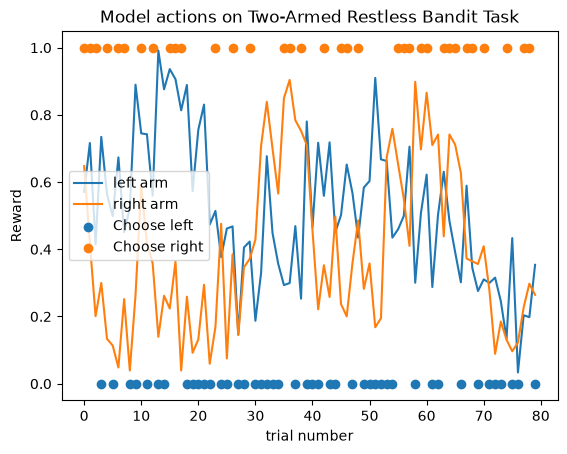

In [13]:
# Your code here
visualize_behavior(bandit_data, actions)

Now, on top of the actions decided by the model, it would be nice to also see the evolution of the probability outputted by your model. What does this mean? Let's just remind ourselves of how decisions are made in this kind of model that integrates some degree of stochasticity. At each time step, the model does the following:  
1. The model has a policy that determines a **probability of choosing one option (the arm on the right)**.
$$p_t \leftarrow \text{model}$$
2. Sample a binary **action** from a Bernoulli distribution parametrized by $p_t$
$$a_t \sim \text{Bernoulli}(p_t)$$

Where:
- $p_t \in [0, 1]$ is the probability of choosing the right arm
- $a_t \in \{0, 1\}$ is the chosen action
    - a == 0 means choosing the left arm
    - a == 1 means choosing the right arm

Since each action $a_t$ is **sampled** from a probability distribution at each trial $t$, we are somehow losing some information about the internal state of the model if we only look at the actions. It would also be interesting to see *to what extent* the model was likely to choose the action. If you remember, when you used the `simulate()` method previously, it returned two arrays, `actions` and `probs`. Now it's time to use `probs` as well!

📝 Now, modify the `visualize_behavior` function to add the variation  over time of the probability of choosing the right arm ($p_t$) to the graph. Write a new version of the function, now called `visualize_behavior_with_probs`, in which you copy the previous code, but also:
- Add an extra argument to the function, `probs`, to pass the array of probabilities
- Add a line plot to represent the probabilities as a separate curve
- Add a label to this line plot to have it mentioned in the legend

Again, don't hesitate to ask for help if you are not familiar with Matplotlib.

In [19]:
def visualize_behavior_with_probs(bandit_data, actions, probs):
    # Your code here
    plt.plot(bandit_data[0], label="left arm")
    plt.plot(bandit_data[1], label="right arm")
    plt.title(f"Model actions on Two-Armed Restless Bandit Task")
    plt.xlabel("trial number")
    plt.ylabel("Reward")
    plt.scatter(np.where(actions==0)[0], actions[actions == 0], label="Choose left")
    plt.scatter(np.where(actions==1)[0], actions[actions==1], label="Choose right")
    plt.plot(probs, label="Probs")
    plt.legend()
    plt.show()

Now, execute your function to visualize the behavior with the model probabilities

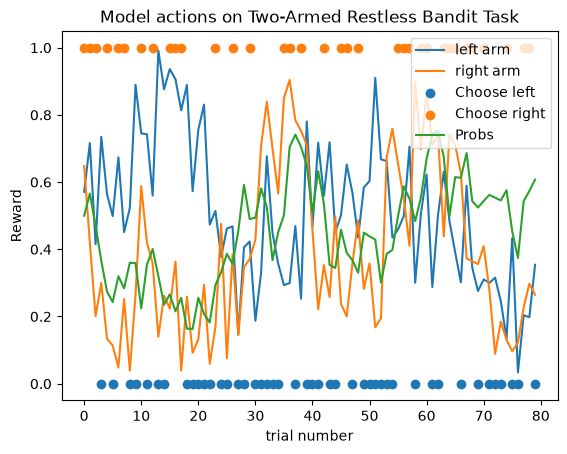

In [20]:
visualize_behavior_with_probs(bandit_data, actions, probs)

### C) Test the impact of the parameter values on the model
The parameter values that you choose for your `RLModel` do matter. They determine how your model processes the rewards obtained in the task. To convince yourself, you will now simulate and visualize behavior with different parameter values and see what it changes. We haven't studied them so far, but you can try to vary the parameters one at a time and try to guess what they do.

📝 Instantiate an `RLModel` with a new set of values for `learning_rate` and `temperature`. Then visualize its behavior like you just did in the previous exercise.
    **_Hint for new coders_**: No need to copy the matplolib code again. You just need to call the function. This part of the exercise should fit in 3 lines of code.

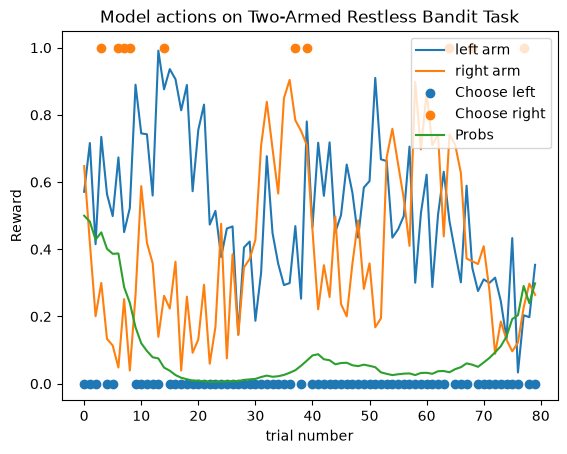

In [25]:
# Your code here (just 3 lines!)
new_rl_model = RLModel(0.01,0.01)
actions, probs = new_rl_model.simulate(bandit_data) 
visualize_behavior_with_probs(bandit_data, actions, probs)

👉Now, repeat the experiment by modifying the parameter values as many times as you want within the range $[0,1]$ and define the role that each parameter plays in behavior generation.

## Fit a model to human data
Now it's time to see how to use the model with real human data. But which data will we use? YOURS!!  
Remember you played the bandit task at the beginning of the exercise? Now it's time to fit a Reinforcement Learning model on it find to out what parameter values best correspond to your behavior.

📝 Now load your behavior data with `np.load('file_name.npy')`. They are saved in two files:
- `my_actions.npy` contains the sequence of actions that you chose
- `my_rewards.npy` contains the rewards you received after each action
  
Load the two NumPy arrays and find out what shape they have to see how to use them with your model.

In [26]:
# Your code here
my_actions = np.load("my_actions.npy") # Fill this
my_rewards = np.load("my_rewards.npy") # Fill this

print(f"actions shape: {my_actions.shape}")
print(f"rewards shape: {my_rewards.shape}")

actions shape: (80,)
rewards shape: (80,)


Now, we will not instantiate the class by calling its constructor with parameter values because **the point is to find out what parameter values correspond to your behavior**. Instead, we will call the classmethod `RLModel.fit(my_actions, my_rewards)`. This method will run an **optimization routine** to find out what parameter set maximizes the likelihood of the model generating your actions given the rewards you got. At the end, the method automatically returns an instance of `RLModel` with the optimal parameters.
📝 Call the `fit()` method to fit an RLModel to your data.  

In [27]:
# Your code here
my_model = RLModel.fit(my_actions, my_rewards) # Call the fit() method on your RLModel class, passing it the my_actions and my_rewards arrays

Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         62.6236               1                                 Uncertainty test
     0           6         50.7349               1         Initial mesh            Initial points
     0           8         50.7349             0.5         Refine grid             Train
     1          10         50.4124             0.5     Incremental search (ES-wcm)        
     1          16         50.4124            0.25         Refine grid             
     2          19         50.3362            0.25     Incremental search (ES-wcm)        
     2          24         50.3362           0.125         Refine grid             
     3          25         50.3053           0.125     Incremental search (ES-ell)        
     3          26         50.3031           0.125     Incremental search (ES-ell)        
     3          27         5

/workspaces/cognitive-modeling-lab/venv/lib/python3.11/site-packages/gpyreg/gaussian_process.py:2477: RuntimeWarning: underflow encountered in divide
  Q = sp.linalg.solve_triangular(
/workspaces/cognitive-modeling-lab/venv/lib/python3.11/site-packages/gpyreg/gaussian_process.py:2488: RuntimeWarning: underflow encountered in multiply
  dnlZ[i] = np.sum(np.sum(Q * dK[:, :, i])) / 2


     3          32         50.3029          0.0625         Refine grid             Train
     4          40         50.3029         0.03125         Refine grid             Train
     5          42         50.3028         0.03125     Incremental search (ES-ell)        
     5          48         50.3028        0.015625         Refine grid             
     6          56         50.3028      0.00390625         Refine grid             
     7          58         50.3028      0.00390625     Incremental search (ES-wcm)        
     7          59         50.3028      0.00390625     Incremental search (ES-wcm)        


/workspaces/cognitive-modeling-lab/venv/lib/python3.11/site-packages/gpyreg/covariance_functions.py:339: RuntimeWarning: underflow encountered in power
  K = sf2 * M ** (-alpha)
/workspaces/cognitive-modeling-lab/venv/lib/python3.11/site-packages/gpyreg/covariance_functions.py:339: RuntimeWarning: underflow encountered in multiply
  K = sf2 * M ** (-alpha)
/workspaces/cognitive-modeling-lab/venv/lib/python3.11/site-packages/gpyreg/gaussian_process.py:2416: RuntimeWarning: underflow encountered in divide
  K / (sn2_div * sn2_mult) + sn2_mat, check_finite=False


     7          64         50.3028     0.000976562         Refine grid             Train
     8          65         50.3028     0.000976562     Incremental search (ES-wcm)        
Optimization terminated: change in the function value less than options['tol_fun'].
Function value at minimum: 50.30277340474954



📝 Access the `learning_rate` and `temperature` **attributes** of your fitted model to find out what parameter values have been found to best characterize your behavior.

In [28]:
# Your code here
learning_rate = my_model.learning_rate # Fill this
temperature = my_model.temperature # Fill this

print(f"learning rate: {learning_rate:.3f}")
print(f"temperature: {temperature:.3f}")

learning rate: 0.784
temperature: 0.286
